In [95]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from ddpg_td3_layernorm_lunar.ddpg import DDPG
from ddpg_td3_layernorm_lunar.replay_buffer import ReplayBuffer
from ddpg_td3_layernorm_lunar.run import run_policy
from ddpg_td3_layernorm_lunar.td3 import TD3

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Most of the following code is based on https://github.com/sfujim/td3

In [96]:
algo = DDPG
seed = 1
layer_normalization = True

In [97]:
# algo = DDPG
# seed = 1
# layer_normalization = True

res = {}
for algo in [DDPG, TD3]:
    for layer_normalization in [False, True]:
        steps = []
        evaluations = []
        biases = []
        for seed in range(20):
            x = np.load(
                f"../results/{algo.__name__}_seed_{seed}_ln_{layer_normalization}.npz"
            )
            steps.append(x["steps"])
            evaluations.append(x["evaluations"])
            biases.append(x["biases"])
        res[f"{algo.__name__}_ln_{layer_normalization}"] = (steps, evaluations, biases)

[len(x) for x in res["DDPG_ln_False"][1]]

[101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101,
 101]

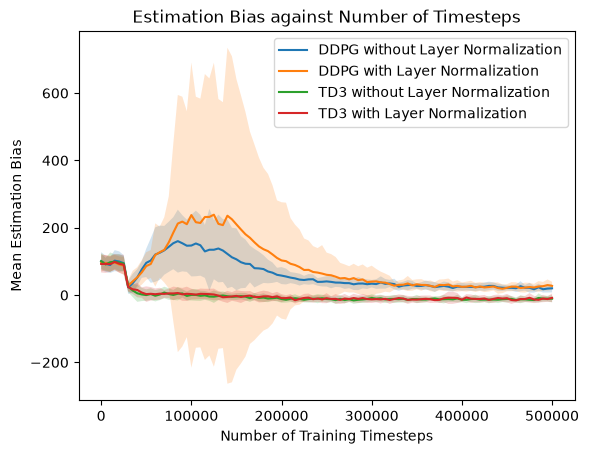

In [98]:
plt.title("Estimation Bias against Number of Timesteps")
for algo in [DDPG, TD3]:
    for layer_normalization in [False, True]:
        x = np.stack(res[f"{algo.__name__}_ln_{layer_normalization}"][0]).mean(0)
        y = np.stack(res[f"{algo.__name__}_ln_{layer_normalization}"][2]).mean(0)
        y_std = np.stack(res[f"{algo.__name__}_ln_{layer_normalization}"][2]).std(0)
        plt.plot(
            x,
            y,
            label=f"{algo.__name__} {'with' if layer_normalization else 'without'} Layer Normalization",
        )
        plt.fill_between(x, y - y_std, y + y_std, alpha=0.2)
plt.xlabel("Number of Training Timesteps")
plt.ylabel("Mean Estimation Bias")
plt.legend()
plt.show()

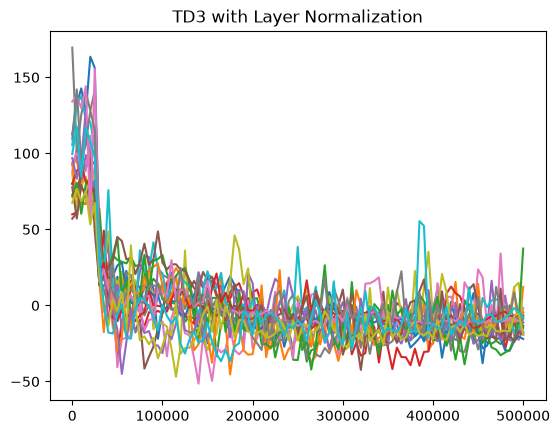

In [103]:
plt.title(
    f"{algo.__name__} {'with' if layer_normalization else 'without'} Layer Normalization"
)
for seed in range(20):
    x = np.load(f"../results/{algo.__name__}_seed_{seed}_ln_{layer_normalization}.npz")
    steps = x["steps"]
    evaluations = x["evaluations"]
    biases = x["biases"]

    plt.plot(steps, biases)
plt.show()

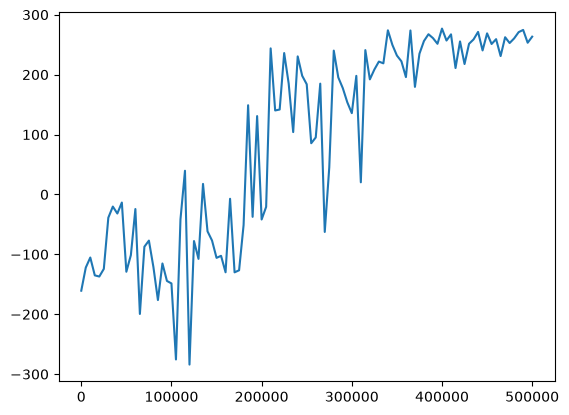

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")